# Assumption in linear regression  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('../../datasets/data.csv')

In [4]:
data.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [5]:
x =  data[['feature1','feature2','feature3']]
y = data[['target']]

In [6]:
x.shape

(200, 3)

In [7]:
y.shape

(200, 1)

In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [9]:
x_train.shape

(140, 3)

In [10]:
y_train.shape

(140, 1)

In [11]:
from sklearn.linear_model import LinearRegression

In [13]:
lr = LinearRegression()

In [14]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
y_pred = lr.predict(x_test)

In [30]:
y_pred
residual = y_test - y_pred

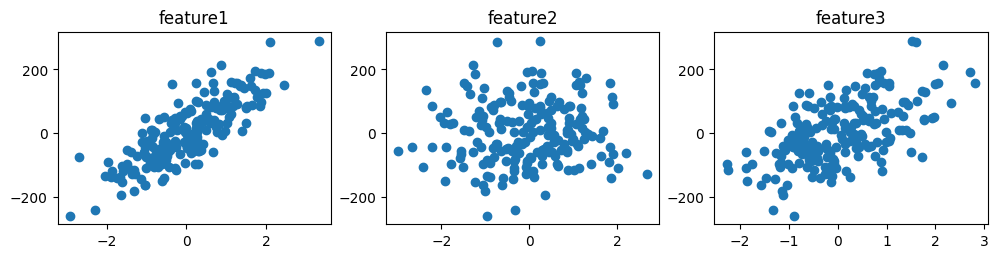

In [19]:
fig, (ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(12,2.5))

ax1.scatter(data['feature1'],data['target'])
ax1.set_title('feature1')

ax2.scatter(data['feature2'],data['target'])
ax2.set_title('feature2')

ax3.scatter(data['feature3'],data['target'])
ax3.set_title('feature3')

plt.show()

# 2. Multicollinearity

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = []
for i in range(x.shape[1]):
    vif.append(variance_inflation_factor(x,i))

In [22]:
pd.DataFrame({'vif':vif},index=data.columns[0:3]).T
# if its value is leasser than 5. It means it has not multicollinearity

,feature1,feature2,feature3
vif,1.002545,1.00341,1.005937


<Axes: >

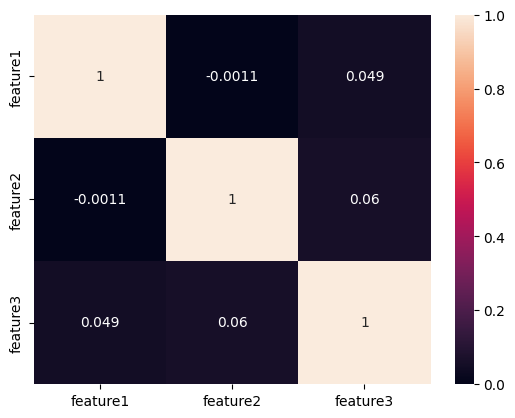

In [27]:
# another technique
sns.heatmap(data.iloc[:,0:3].corr(),annot=True)

# 3. Normal Residual

<Axes: ylabel='Count'>

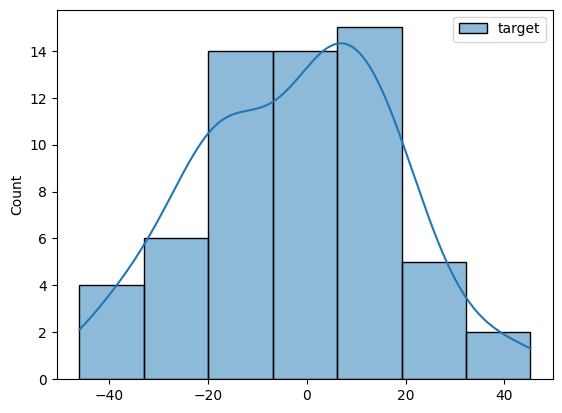

In [32]:
sns.histplot(residual, kde=True)  

ValueError: Cannot calculate a linear regression if all x values are identical

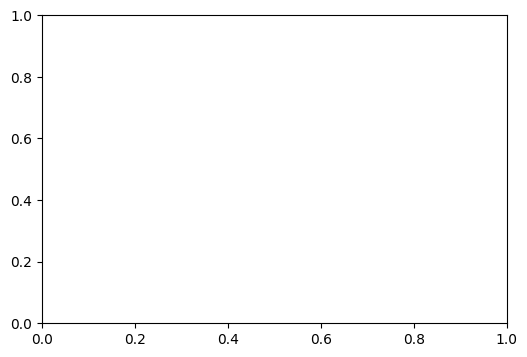

In [35]:
# QQ plot
import scipy as sp
fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual,plot=ax,fit=True)

# Homoscedasticity

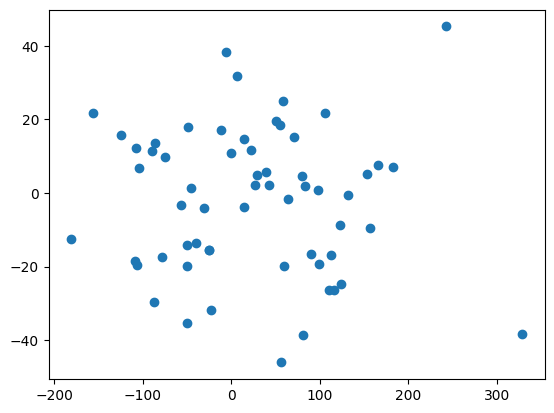

In [36]:
plt.scatter(y_pred,residual)

# 5. Autocorelation

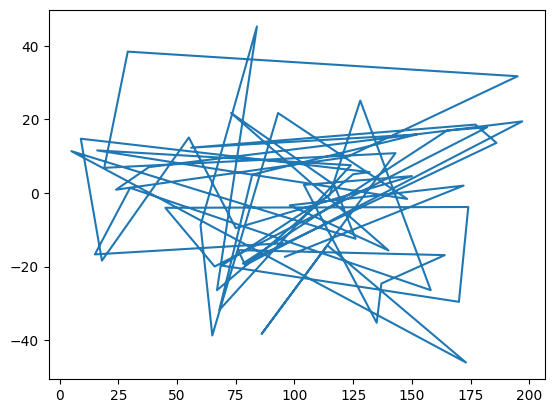

In [39]:
plt.plot(residual) # -> plot should have no specific pattern